# Two Moons — Network Selection HPO

This notebook shows how to use `bayesflow_hpo` to **automatically compare different inference network architectures** on the classic [Two Moons](https://bayesflow.org/main/_examples/Two_Moons_Starter.html) benchmark.

Instead of manually training each network type (as in the original example), we set up a single Optuna study with a `NetworkSelectionSpace` that searches across **Flow Matching**, **Coupling Flow**, and **Consistency Model** simultaneously — optimizing both the network choice and its hyperparameters.

See the [getting started notebook](getting_started.ipynb) for a general introduction to `bayesflow_hpo`.

In [1]:
%pip install --quiet --upgrade -e ..

import numpy as np
import bayesflow as bf
import keras
import bayesflow_hpo as hpo

Note: you may need to restart the kernel to use updated packages.


INFO:bayesflow:Using backend 'torch'
When using torch backend, we need to disable autograd by default to avoid excessive memory usage. Use

with torch.enable_grad():
    ...

in contexts where you need gradients (e.g. custom training loops).
c:\Users\Matze\Documents\GitHub\bayesflow_projects\bayesflow_hpo\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Simulator & Adapter

The Two Moons model has a 2-D uniform prior and a stochastic forward model that produces a characteristic crescent-shaped posterior. See the [original example](https://bayesflow.org/main/_examples/Two_Moons_Starter.html) for details.

We represent the two latent parameters as separate keys (`theta_1`, `theta_2`) and concatenate them into `inference_variables` so validation metrics receive the correct variable count.

Since the observations `x` are fixed-size vectors (not sets), we route them to `summary_variables` and use an identity summary network. This keeps the representation unchanged while satisfying `check_pipeline()` key inference.

In [3]:
def prior():
    theta = np.random.uniform(-1, 1, 2).astype("float32")
    return {
        "theta_1": np.array([theta[0]], dtype="float32"),
        "theta_2": np.array([theta[1]], dtype="float32"),
    }


def forward_model(theta_1, theta_2):
    theta = np.array([float(theta_1[0]), float(theta_2[0])], dtype="float32")
    alpha = np.random.uniform(-np.pi / 2, np.pi / 2)
    r = np.random.normal(0.1, 0.01)
    x1 = -np.abs(theta[0] + theta[1]) / np.sqrt(2) + r * np.cos(alpha) + 0.25
    x2 = (-theta[0] + theta[1]) / np.sqrt(2) + r * np.sin(alpha)
    return dict(x=np.array([x1, x2], dtype="float32"))


simulator = bf.make_simulator([prior, forward_model])
adapter = (
    bf.Adapter()
    .concatenate(["theta_1", "theta_2"], into="inference_variables", axis=-1)
    .rename("x", "summary_variables")
)

## 2. Network Selection Search Space

The key ingredient: `NetworkSelectionSpace` wraps multiple inference network spaces and adds a categorical Optuna parameter (`inference_network_type`) that selects which one to use in each trial. Optuna then jointly optimizes the network choice and its architecture hyperparameters.

In [4]:
from typing import Any, cast

class IdentitySummaryNetwork(bf.networks.SummaryNetwork):
    def __init__(self):
        super().__init__()
        self._flatten = keras.layers.Flatten()

    def call(self, x, **kwargs):
        return self._flatten(x)


class IdentitySummarySpace:
    dimensions: tuple[Any, ...] = ()

    def sample(self, trial):
        return {}

    def build(self, params):
        return IdentitySummaryNetwork()


search_space = hpo.CompositeSearchSpace(
    inference_space=cast(Any, hpo.NetworkSelectionSpace(
        candidates={
            "flow_matching": hpo.FlowMatchingSpace(),
            "coupling_flow": hpo.CouplingFlowSpace(),
            "consistency_model": hpo.ConsistencyModelSpace(),
        }
    )),
    summary_space=cast(Any, IdentitySummarySpace()),
    training_space=hpo.TrainingSpace(),
)

## 3. Run HPO

We run a small study (8 trials) to compare the three network types. In practice, increase `n_trials` for more thorough exploration.

In [ ]:
from typing import Any
from bayesflow_hpo.validation.inference import make_bayesflow_infer_fn
from bayesflow_hpo.validation.metrics import aggregate_condition_rows, compute_condition_metrics
from bayesflow_hpo.validation.registry import resolve_metrics

# Change this one value to switch optimization target.
OBJECTIVE_METRIC = "sbc_ks"

# Keep validation broad; objective metric is auto-included below.
VALIDATION_METRICS = ["calibration_error", "nrmse", "sbc_ks"]


def train_fn(approximator, simulator, hparams, callbacks):
    """Compatibility hook for BayesFlow 2.0.8+ (maps batches_per_epoch -> num_batches)."""
    approximator.fit(
        simulator=simulator,
        epochs=int(hparams["epochs"]),
        batch_size=int(hparams.get("batch_size", 256)),
        num_batches=int(hparams["batches_per_epoch"]),
        callbacks=callbacks,
    )


def validate_fn(approximator, validation_data, n_posterior_samples):
    """Compute metrics for scalar or vector parameters and return summary dict."""
    metric_names = list(VALIDATION_METRICS)
    if OBJECTIVE_METRIC not in metric_names:
        metric_names.append(OBJECTIVE_METRIC)
    metric_fns = resolve_metrics(metric_names)

    infer_fn = make_bayesflow_infer_fn(
        approximator=approximator,
        param_keys=validation_data.param_keys,
        data_keys=validation_data.data_keys,
    )

    rows = []
    for cond_id, sim_batch in enumerate(validation_data.simulations):
        draws = np.asarray(infer_fn(sim_batch, n_posterior_samples))
        param_keys = list(validation_data.param_keys)

        per_param_rows = []

        # Case A: multiple scalar parameter keys (e.g., theta_1, theta_2)
        if len(param_keys) > 1:
            if draws.ndim != 3:
                raise ValueError(
                    f"Expected draws with shape (n_sims, n_samples, n_params), got {draws.shape}."
                )
            if draws.shape[-1] != len(param_keys):
                raise ValueError(
                    f"Posterior/param_keys mismatch: draws has {draws.shape[-1]} params, "
                    f"param_keys has {len(param_keys)}."
                )

            for j, key in enumerate(param_keys):
                true_values = np.asarray(sim_batch[key]).reshape(-1)
                row = compute_condition_metrics(
                    draws=np.asarray(draws[:, :, j]),
                    true_values=true_values,
                    cond_id=cond_id,
                    metric_fns=metric_fns,
                )
                per_param_rows.append(row)

        # Case B: single key that may still be vector-valued (e.g., theta -> (..., 2))
        else:
            key = param_keys[0]
            true_values = np.asarray(sim_batch[key])

            if draws.ndim == 2:
                draws = draws[:, :, None]
            if true_values.ndim == 1:
                true_values = true_values[:, None]

            if draws.ndim != 3:
                raise ValueError(f"Expected draws with 3 dims, got shape {draws.shape}.")
            if true_values.ndim != 2:
                raise ValueError(f"Expected targets with 2 dims, got shape {true_values.shape}.")

            n_draw_params = int(draws.shape[-1])
            n_true_params = int(true_values.shape[-1])
            if n_draw_params != n_true_params:
                raise ValueError(
                    f"Posterior/target parameter mismatch: draws has {n_draw_params}, "
                    f"targets have {n_true_params}."
                )

            for j in range(n_draw_params):
                row = compute_condition_metrics(
                    draws=np.asarray(draws[:, :, j]),
                    true_values=np.asarray(true_values[:, j]).reshape(-1),
                    cond_id=cond_id,
                    metric_fns=metric_fns,
                )
                per_param_rows.append(row)

        combined: dict[str, Any] = {"condition_id": cond_id}
        combined.update(aggregate_condition_rows(per_param_rows))
        rows.append(combined)

    summary = aggregate_condition_rows(rows)
    if "sbc_ks" in summary and not np.isfinite(summary["sbc_ks"]):
        summary["sbc_ks"] = 1.0
    return summary

In [6]:
hpo.describe_metrics()

Name,Kind,Aliases,Description
bias,objective,—,"Mean signed error (positive=overestimate, negative=underestimate)."
calibration_error,objective,cal_error,Expected Calibration Error (ECE) via BayesFlow diagnostics.
contraction,objective,—,"Posterior contraction (1 = strong learning, 0 = no narrowing)."
correlation,objective,corr,Pearson correlation between posterior means and true values.
coverage,diagnostic,coverage_two_sided,Two-sided SBC rank coverage at standard credible-interval levels.
coverage_left,diagnostic,—,Left-sided coverage (statistical efficiency).
coverage_right,diagnostic,—,Right-sided coverage (futility / conservatism).
log_gamma,objective,—,Log-gamma calibration diagnostic from BayesFlow.
mae,objective,—,Mean Absolute Error of posterior means vs true values.
nrmse,objective,—,Range-normalized RMSE (comparable across parameter scales).


In [7]:
study = hpo.optimize(
    simulator=simulator,
    adapter=adapter,
    search_space=search_space,
    n_trials=8,
    epochs=30,
    batches_per_epoch=50,
    sims_per_condition=32,
    max_param_count=500_000,
    objective_metrics=[OBJECTIVE_METRIC],
    objective_mode="pareto",
    train_fn=train_fn,
    validate_fn=validate_fn,
    storage=None,
    show_progress_bar=False,
)

INFO:bayesflow:Building dataset from simulator instance of SequentialSimulator.
INFO:bayesflow:Using 16 data loading workers.
INFO:bayesflow:Building on a test batch.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - loss: 2.9922


Sampling: 100%|██████████| 1/1 [00:02<00:00,  2.17s/batch]
c:\Users\Matze\Documents\GitHub\bayesflow_projects\bayesflow_hpo\.venv\Lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(
c:\Users\Matze\Documents\GitHub\bayesflow_projects\bayesflow_hpo\.venv\Lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``constraints_func`` is an experimental feature. The interface can change in the future.
  optuna_warn(
[I 2026-03-17 17:06:49,907] A new study created in memory with name: bayesflow_hpo
INFO:bayesflow_hpo.optimization.study:Starting HPO: target 8 trained trials (max 24 non-rejected, hard cap 120).
  trained  = completed training + validation successfully
  rejected = skipped before training (model too large or failed to build)
  failed   = crashed during training
  pruned   = stopped early by intermediate validation (unpromising)
INFO:bayes

Epoch 1/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 120ms/step - loss: 1.0234 - moving_avg_loss: 1.0234
Epoch 2/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 122ms/step - loss: 0.2053 - moving_avg_loss: 0.6144
Epoch 3/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 119ms/step - loss: -0.1120 - moving_avg_loss: 0.3723
Epoch 4/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 121ms/step - loss: -0.1053 - moving_avg_loss: 0.2529
Epoch 5/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 121ms/step - loss: -0.5186 - moving_avg_loss: 0.0986
Epoch 6/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 120ms/step - loss: -0.6454 - moving_avg_loss: -0.0254
Epoch 7/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 119ms/step - loss: -0.6285 - moving_avg_loss: -0.1116
Epoch 8/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 118ms/step - loss: -0.6204 - moving_avg_loss: -0.3464
Epoch 9/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 123ms/step - loss: -0.8880 - moving_avg_loss: -0.5026
Epoch 10/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 141ms/step - loss: -1.0143 - moving_avg_loss: -0.6315
Epoch 11/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - l

Sampling: 100%|██████████| 1/1 [00:00<00:00, 11.53batch/s]


...

Sampling: 100%|██████████| 1/1 [00:00<00:00,  1.30batch/s]
[I 2026-03-17 17:27:37,849] Trial 9 pruned. 
INFO:bayesflow_hpo.optimization.study:Progress: 7/8 trained | 3 pruned | best sbc_ks: 0.1677 | best inference_time: 0.5969
INFO:bayesflow:Building dataset from simulator instance of SequentialSimulator.
INFO:bayesflow:Using 16 data loading workers.


Epoch 1/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 103ms/step - loss: 0.5487 - moving_avg_loss: 0.5487
Epoch 2/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 93ms/step - loss: 0.4402 - moving_avg_loss: 0.4944
Epoch 3/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 103ms/step - loss: 0.4121 - moving_avg_loss: 0.4670
Epoch 4/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 98ms/step - loss: 0.3833 - moving_avg_loss: 0.4461
Epoch 5/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - loss: 0.3997 - moving_avg_loss: 0.4368
Epoch 6/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - loss: 0.3712 - moving_avg_loss: 0.4258
Epoch 7/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 95ms/step - loss: 0.3591 - moving_avg_loss: 0.4163
Epoch 8/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 92ms/step - loss: 0.3532 - moving_avg_loss: 0.3884
Epoch 9/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - loss: 0.3476 - moving_avg_loss: 0.3752
Epoch 10/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 93ms/step - loss: 0.4683 - moving_avg_loss: 0.3832
Epoch 11/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - loss: 0.4151

Sampling: 100%|██████████| 1/1 [00:00<00:00,  3.28batch/s]


50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 105ms/step - loss: 0.4151 - moving_avg_loss: 0.3877
Epoch 12/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - loss: 0.4155 - moving_avg_loss: 0.3900
Epoch 13/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 94ms/step - loss: 0.3941 - moving_avg_loss: 0.3933
Epoch 14/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 99ms/step - loss: 0.3739 - moving_avg_loss: 0.3954


Sampling: 100%|██████████| 1/1 [00:00<00:00,  3.03batch/s]
INFO:bayesflow_hpo.optimization.objective:Trial #10 done (76s) | params: 9.0K | sbc_ks: 0.4490 | inference_time_s: 0.34s
[I 2026-03-17 17:28:54,887] Trial 10 finished with values: [0.4490082335329341, 0.3397477000253275] and parameters: {'inference_network_type': 'consistency_model', 'cm_subnet_width': 32, 'cm_subnet_depth': 3, 'cm_dropout': 0.023173811905025946, 'initial_lr': 0.002926758115062129}.
INFO:bayesflow_hpo.optimization.study:Progress: 8/8 trained | 3 pruned | best sbc_ks: 0.1677 | best inference_time: 0.5969
INFO:bayesflow_hpo.optimization.study:Completed 8 trained, 3 pruned.


## 4. Results

In [8]:
summary = hpo.summarize_study(study)

Study: bayesflow_hpo
Trials: 11 total | 8 trained | 0 rejected | 3 pruned | 0 failed
Objectives: sbc_ks, inference_time

Pareto front: 3 trials
Best trial: #8
  sbc_ks                        : 0.1677
  inference_time (s)            : 0.6
  param_count                   : 44.9K

Use trial_table() for detailed results, best_config() for hyperparameters.


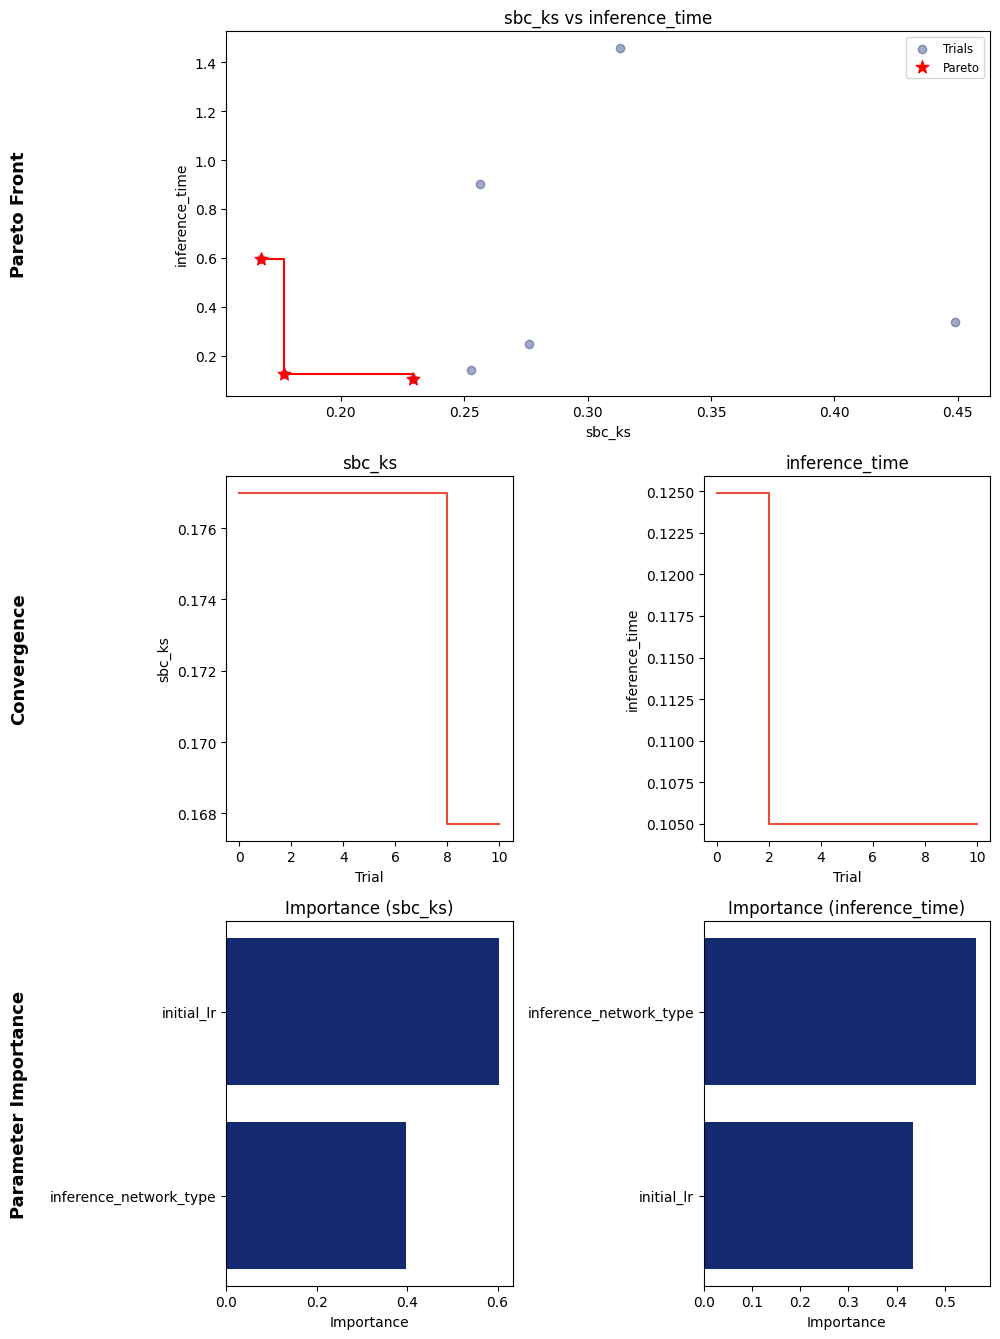

In [9]:
fig = hpo.plot_study(study)

### Trial Table

The `inference_network_type` column shows which network Optuna selected for each trial, making it easy to compare performance across architectures.

In [10]:
df = hpo.trials_to_dataframe(study)

key_cols = [
    "rank","trial_number", "inference_network_type",
    "calibration_error", "nrmse", "correlation", "sbc_ks",
    "coverage_90", "param_count", "inference_time_s",
]
display_cols = [c for c in key_cols if c in df.columns]
df.sort_values("calibration_error")[display_cols]

,rank,trial_number,inference_network_type,calibration_error,nrmse,sbc_ks,param_count,inference_time_s
5,5,6,consistency_model,0.036513,0.208463,0.256331,47581,0.9032
0,2,0,coupling_flow,0.059918,0.191027,0.176990,4690,0.1249
6,1,8,consistency_model,0.085888,0.189854,0.167696,44861,0.5969
2,3,2,coupling_flow,0.124918,0.181606,0.229198,7738,0.1050
3,4,3,coupling_flow,0.137878,0.188766,0.252807,9670,0.1434
4,7,4,consistency_model,0.148470,0.234890,0.312999,219325,1.4580
7,8,10,consistency_model,0.166678,0.216448,0.449008,8989,0.3397
1,6,1,coupling_flow,0.197911,0.188790,0.276104,21610,0.2486


### Best Configuration

In [11]:
table = hpo.trial_table(study, top_k=5, metrics=["correlation", "coverage_90"])
table

rank,trial,sbc_ks,inference_time,param_count,cm_dropout,cm_subnet_depth,cm_subnet_width,inference_network_type,initial_lr,cf_depth,cf_dropout,cf_subnet_depth,cf_subnet_width
1,8,0.167700,0.600000,44.9K,0.110000,2.000000,96.000000,consistency_model,1.74e-04,nan,nan,nan,nan
2,0,0.177000,0.100000,4.7K,nan,nan,nan,coupling_flow,2.96e-03,6.000000,0.020000,1.000000,64.000000
3,2,0.229200,0.100000,7.7K,nan,nan,nan,coupling_flow,4.19e-04,4.000000,0.090000,1.000000,160.000000
4,3,0.252800,0.100000,9.7K,nan,nan,nan,coupling_flow,1.95e-04,5.000000,0.180000,1.000000,160.000000
5,6,0.256300,0.900000,47.6K,0.160000,6.000000,64.000000,consistency_model,3.95e-03,nan,nan,nan,nan


In [12]:
config = hpo.best_config(study)


Hyperparameters (trial #8)
--------------------------
  cm_dropout                         : 0.11
  cm_subnet_depth                    : 2
  cm_subnet_width                    : 96
  inference_network_type             : consistency_model
  initial_lr                         : 1.74e-04


## 5. Retrain Best Model

Rebuild the winning architecture from the HPO config and retrain with a larger budget.

In [13]:
from typing import Any, cast
import keras

approximator = hpo.build_continuous_approximator(config, adapter, search_space)

epochs, batches_per_epoch = 50, 100
lr_schedule = keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=float(config["initial_lr"]),
    decay_steps=epochs * batches_per_epoch,
 )
approximator.compile(optimizer=keras.optimizers.Adam(learning_rate=cast(Any, lr_schedule)))

approximator.fit(
    simulator=simulator,
    epochs=epochs,
    num_batches=batches_per_epoch,
    batch_size=int(config.get("batch_size", 256)),
)

INFO:bayesflow:Building dataset from simulator instance of SequentialSimulator.
INFO:bayesflow:Using 16 data loading workers.
INFO:bayesflow:Building on a test batch.


Epoch 1/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 96ms/step - loss: 0.5855
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 95ms/step - loss: 0.4740
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 96ms/step - loss: 0.4318
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 92ms/step - loss: 0.4101
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 103ms/step - loss: 0.3878
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 93ms/step - loss: 0.3807
Epoch 7/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 93ms/step - loss: 0.3715
Epoch 8/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 92ms/step - loss: 0.3672
Epoch 9/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 93ms/step - loss: 0.3567
Epoch 10/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 93ms/step - loss: 0.3566
Epoch 11/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 93ms/step - loss: 0.3488
Epoch 12/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 91ms/step - loss: 0.3457
Epoch 13/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 92ms/step - loss: 0.3439
Epoch 14/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 92ms/step - loss: 0.3390
Epoch 15/50
100/100 ━━━━━━━━

### Posterior Samples

Draw posterior samples at the canonical observation $x = (0, 0)$ to verify the characteristic crescent shape.

Sampling: 100%|██████████| 1/1 [00:00<00:00,  6.28batch/s]


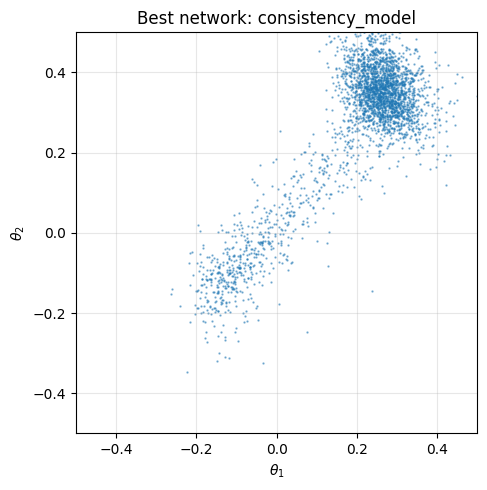

In [14]:
import matplotlib.pyplot as plt

conditions = {"x": np.array([[0.0, 0.0]], dtype="float32")}
draws = approximator.sample(conditions=conditions, num_samples=3000)

if isinstance(draws, dict):
    if "theta" in draws:
        samples = draws["theta"]
    elif "theta_1" in draws and "theta_2" in draws:
        samples = np.concatenate([draws["theta_1"], draws["theta_2"]], axis=-1)
    else:
        raise KeyError(f"Could not find posterior samples. Available keys: {list(draws.keys())}")
else:
    samples = draws

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(samples[0, :, 0], samples[0, :, 1], alpha=0.5, s=0.5)
ax.set(xlabel=r"$\theta_1$", ylabel=r"$\theta_2$", xlim=(-0.5, 0.5), ylim=(-0.5, 0.5))
ax.set_aspect("equal")
ax.set_title(f"Best network: {config.get('inference_network_type', 'N/A')}")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
from bayesflow_hpo.api import infer_keys_from_adapter

print(infer_keys_from_adapter(adapter))
for t in adapter.transforms:
    print(type(t).__name__, getattr(t, "__dict__", {}))

{'param_keys': ['theta_1', 'theta_2'], 'data_keys': ['x'], 'inference_conditions': None}
Concatenate {'keys': ['theta_1', 'theta_2'], 'into': 'inference_variables', 'axis': -1, 'indices': [1, 2]}
Rename {'from_key': 'x', 'to_key': 'summary_variables'}
